In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

In [2]:
# get best track data for typhoon Ragasa
best_track_ragasa = pd.read_excel("./data/best_track_Ragasa_JMA.xlsx")
best_track_ragasa

,Time,Lat,Lon,Pres,Wind
0,25091818,158,1322,1000,35
1,25091900,156,1316,998,40
2,25091906,157,1309,994,45
3,25091912,159,1305,992,50
4,25091918,162,1301,990,55
5,25092000,164,1296,985,60
6,25092006,168,1290,980,65
7,25092012,173,1285,960,80
8,25092018,178,1277,955,85
9,25092100,180,1270,940,95


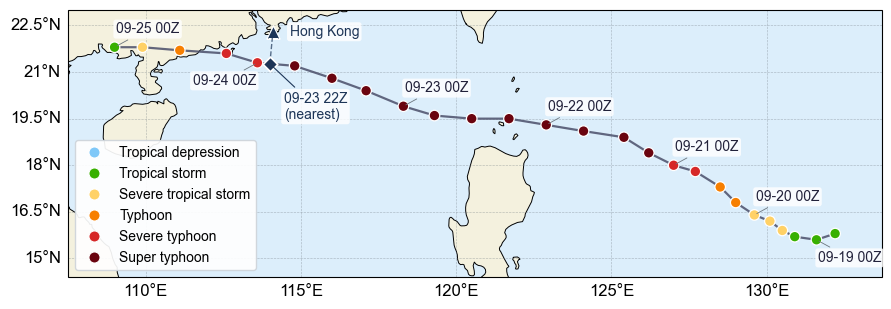

In [3]:
# plot best track
FONT_FAMILY = 'Arial'
TICK_FONTSIZE = 12
TEXT_FONTSIZE = 10
LABEL_BOX = dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.82)
TIME_LABEL_OFFSETS = [
    (1, -8),
    (1, 8),
    (1, 8),
    (1, 8),
    (1, 8),
    (-1, -8),
    (1, 8),
]

plt.rcParams['font.family'] = FONT_FAMILY

track = best_track_ragasa.copy()
track['time_utc'] = pd.to_datetime(track['Time'].astype(str), format='%y%m%d%H')
track['lat_deg'] = track['Lat'] / 10.0
track['lon_deg'] = track['Lon'] / 10.0
track['wind_ms'] = track['Wind'] * 0.514444

hong_kong_lat = 22.3
hong_kong_lon = 114.1

category_specs = [
    ('Tropical depression', 10.8, 17.1, '#7fc8f8'),
    ('Tropical storm', 17.2, 24.4, '#38b000'),
    ('Severe tropical storm', 24.5, 32.6, '#ffd166'),
    ('Typhoon', 32.7, 41.4, '#f77f00'),
    ('Severe typhoon', 41.5, 50.9, '#d62828'),
    ('Super typhoon', 51.0, np.inf, '#6a040f'),
]

def classify_cn_typhoon(wind_ms):
    for label, lower, upper, color in category_specs:
        if lower <= wind_ms <= upper:
            return label, color
    return 'Below tropical depression', '#9e9e9e'

track[['category', 'color']] = track['wind_ms'].apply(
    lambda value: pd.Series(classify_cn_typhoon(value))
)

# Interpolate track position at 09-23 22:00 UTC
target_time = pd.Timestamp('2025-09-23 22:00:00')
time_numeric = track['time_utc'].astype(np.int64)
target_numeric = target_time.value
nearest_lat = np.interp(target_numeric, time_numeric, track['lat_deg'])
nearest_lon = np.interp(target_numeric, time_numeric, track['lon_deg'])

lon_padding = 1.5
lat_padding = 1.2
extent = [
    track['lon_deg'].min() - lon_padding,
    track['lon_deg'].max() + lon_padding,
    track['lat_deg'].min() - lat_padding,
    track['lat_deg'].max() + lat_padding,
]

fig = plt.figure(figsize=(10.5, 5.8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.set_facecolor('#dceefb')
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#f4f1de', edgecolor='none', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#dceefb', edgecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.7, zorder=1)

gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=0.45,
    color='#6c757d',
    alpha=0.45,
    linestyle='--'
)
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xlabel_style = {'size': TICK_FONTSIZE, 'family': FONT_FAMILY}
gridlines.ylabel_style = {'size': TICK_FONTSIZE, 'family': FONT_FAMILY}

ax.plot(
    track['lon_deg'],
    track['lat_deg'],
    color='#4a4e69',
    linewidth=1.6,
    alpha=0.85,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

ax.scatter(
    track['lon_deg'],
    track['lat_deg'],
    c=track['color'],
    s=58,
    edgecolors='white',
    linewidths=0.9,
    transform=ccrs.PlateCarree(),
    zorder=3,
)

ax.scatter(
    hong_kong_lon,
    hong_kong_lat,
    marker='^',
    s=90,
    facecolor='#1d3557',
    edgecolor='white',
    linewidth=0.9,
    transform=ccrs.PlateCarree(),
    zorder=4,
)
ax.annotate(
    'Hong Kong',
    xy=(hong_kong_lon, hong_kong_lat),
    xytext=(62, 5),
    textcoords='offset points',
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color='#1d3557',
    ha='right',
    va='top',
    bbox=LABEL_BOX,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Mark the interpolated nearest point (09-23 22:00 UTC)
# Dashed line from nearest point to Hong Kong
ax.plot(
    [nearest_lon, hong_kong_lon],
    [nearest_lat, hong_kong_lat],
    color='#1d3557',
    linewidth=1.0,
    linestyle='--',
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=4,
)

# Highlight the nearest point with a diamond marker
ax.scatter(
    nearest_lon,
    nearest_lat,
    marker='D',
    s=55,
    facecolor='#1d3557',
    edgecolors='white',
    linewidths=1.2,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Label the nearest point (right bottom)
ax.annotate(
    '09-23 22Z\n(nearest)',
    xy=(nearest_lon, nearest_lat),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color='#1d3557',
    ha='left',
    va='top',
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle='-', color='#1d3557', linewidth=0.8),
    transform=ccrs.PlateCarree(),
    zorder=5,
)

label_indices = track.index[track['time_utc'].dt.hour == 0]
for order, idx in enumerate(label_indices):
    row = track.loc[idx]
    x_offset, y_offset = TIME_LABEL_OFFSETS[order % len(TIME_LABEL_OFFSETS)]
    ax.annotate(
        row['time_utc'].strftime('%m-%d %HZ'),
        xy=(row['lon_deg'], row['lat_deg']),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        fontsize=TEXT_FONTSIZE,
        fontfamily=FONT_FAMILY,
        color='#22223b',
        ha='left' if x_offset >= 0 else 'right',
        va='bottom' if y_offset >= 0 else 'top',
        bbox=LABEL_BOX,
        arrowprops=dict(arrowstyle='-', color='#6c757d', linewidth=0.6),
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markeredgecolor='white',
           markeredgewidth=0.8, markersize=8, label=label)
    for label, _, _, color in category_specs
]
ax.legend(
    handles=legend_handles,
    loc='lower left',
    frameon=True,
    framealpha=0.92,
    facecolor='white',
    edgecolor='#ced4da',
    fontsize=TEXT_FONTSIZE,
    prop={'family': FONT_FAMILY, 'size': TEXT_FONTSIZE},
)


plt.savefig('best_track_ragasa.tif', dpi=600, bbox_inches='tight')
plt.show()